<a href="https://colab.research.google.com/github/keerthanaponugumati/research-projects/blob/main/gw_waves_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
duration = 1.0
sample_rate = 256
n_samples = int(duration * sample_rate)

t = np.linspace(0, duration, n_samples)

print("Number of samples:", n_samples)
print("First 5 time values:", t[:5])

Number of samples: 256
First 5 time values: [0.         0.00392157 0.00784314 0.01176471 0.01568627]


In [ ]:
frequency = 40
amplitude = 1.0

h = amplitude * np.sin(2 * np.pi * frequency * t)

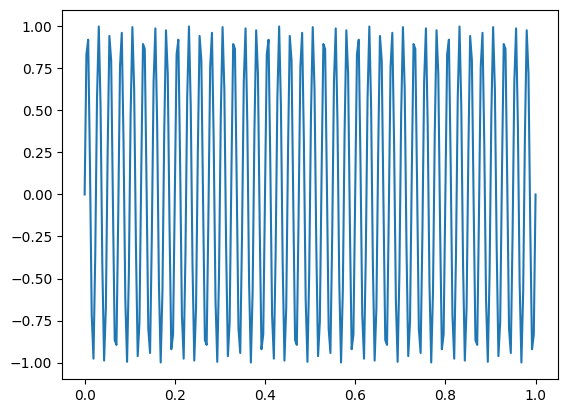

In [ ]:
plt.plot(t, h)
plt.show()

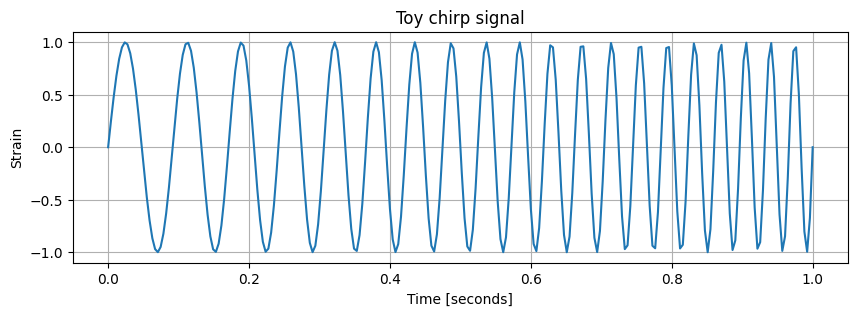

In [ ]:
f_start = 10
f_end = 30

phase = 2 * np.pi * (
    f_start * t + 0.5 * (f_end - f_start) * t**2 / duration
)

chirp = np.sin(phase)

plt.figure(figsize=(10, 3))
plt.plot(t, chirp)
plt.xlabel("Time [seconds]")
plt.ylabel("Strain")
plt.title("Toy chirp signal")
plt.grid(True)
plt.show()

In [ ]:
def simulate_toy_gw(m1, m2, t, duration):
    # Keep the convention m1 >= m2
    if m2 > m1:
        m1, m2 = m2, m1

    # Useful mass combinations
    mass_ratio = m2 / m1
    chirp_mass = (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

    # ----- Frequency rule -----
    # Toy idea: heavier systems end at lower frequency
    base_frequency = 150
    mass_frequency_strength = 2.2

    f_start = 10
    f_end = base_frequency - mass_frequency_strength * chirp_mass
    f_end = np.clip(f_end, 30, 140)

    # ----- Chirp phase -----
    phase = 2 * np.pi * (
        f_start * t + 0.5 * (f_end - f_start) * t**2 / duration
    )

    # ----- Envelope rule -----
    # Toy idea: signal gets louder near the end
    start_envelope = 0.2
    end_envelope = 1.0

    envelope = start_envelope + (end_envelope - start_envelope) * t / duration

    # ----- Amplitude rule -----
    # Toy idea: equal-mass systems are a bit louder
    min_amplitude = 0.6
    max_amplitude = 1.0

    amplitude = min_amplitude + (max_amplitude - min_amplitude) * mass_ratio

    # Final fake gravitational-wave strain
    h = amplitude * envelope * np.sin(phase)

    return h

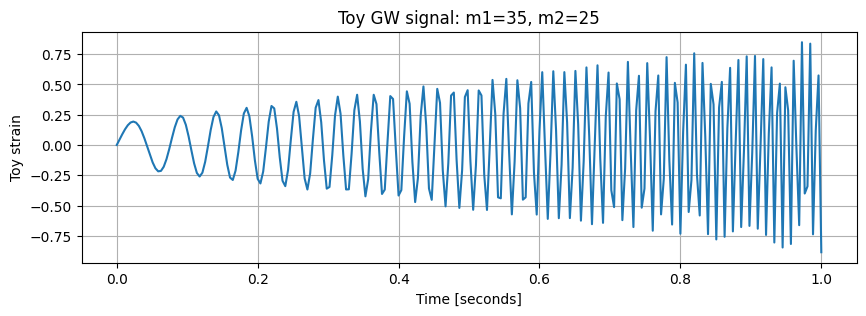

In [ ]:
h = simulate_toy_gw(35, 25, t, duration)

plt.figure(figsize=(10, 3))
plt.plot(t, h)
plt.xlabel("Time [seconds]")
plt.ylabel("Toy strain")
plt.title("Toy GW signal: m1=35, m2=25")
plt.grid(True)
plt.show()

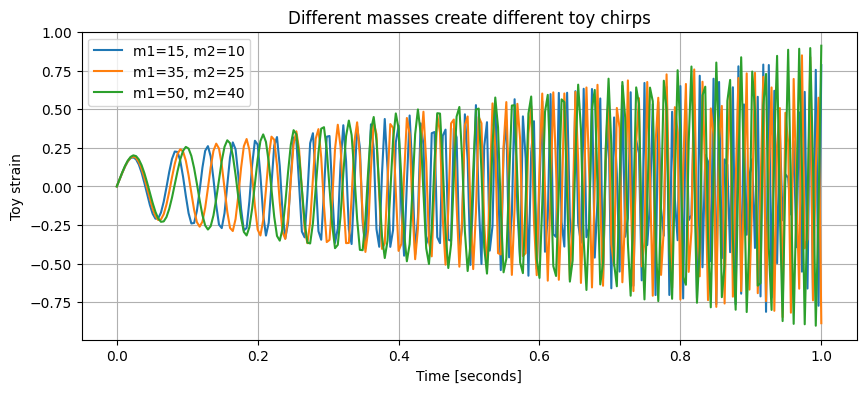

In [ ]:
h_light = simulate_toy_gw(15, 10, t, duration)
h_medium = simulate_toy_gw(35, 25, t, duration)
h_heavy = simulate_toy_gw(50, 40, t, duration)

plt.figure(figsize=(10, 4))
plt.plot(t, h_light, label="m1=15, m2=10")
plt.plot(t, h_medium, label="m1=35, m2=25")
plt.plot(t, h_heavy, label="m1=50, m2=40")
plt.xlabel("Time [seconds]")
plt.ylabel("Toy strain")
plt.title("Different masses create different toy chirps")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def add_noise(h, noise_std=0.3):
    noise = np.random.normal(0, noise_std, size=h.shape)
    d = h + noise
    return d

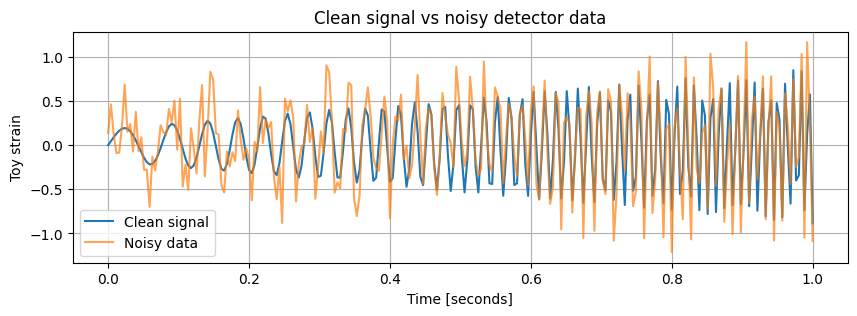

In [ ]:
h_clean = simulate_toy_gw(35, 25, t, duration)
d_noisy = add_noise(h_clean, noise_std=0.3)

plt.figure(figsize=(10, 3))
plt.plot(t, h_clean, label="Clean signal")
plt.plot(t, d_noisy, label="Noisy data", alpha=0.7)
plt.xlabel("Time [seconds]")
plt.ylabel("Toy strain")
plt.title("Clean signal vs noisy detector data")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def sample_masses():
    m1 = np.random.uniform(10, 80)
    m2 = np.random.uniform(10, 80)

    # Keep convention m1 >= m2
    if m2 > m1:
        m1, m2 = m2, m1

    return m1, m2

In [ ]:
def generate_one_example(noise_std=0.3):
    m1, m2 = sample_masses()

    h = simulate_toy_gw(m1, m2, t, duration)
    d = add_noise(h, noise_std=noise_std)

    x = d
    y = np.array([m1, m2])

    return x, y

x shape: (256,)
y: [23.0710493  10.58234546]


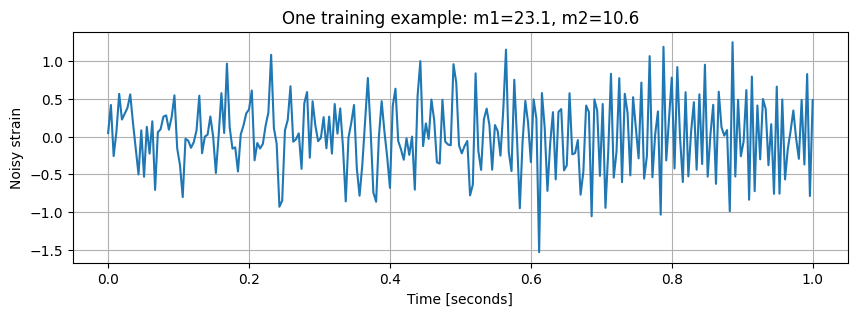

In [ ]:
x, y = generate_one_example(noise_std=0.3)

print("x shape:", x.shape)
print("y:", y)

plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.xlabel("Time [seconds]")
plt.ylabel("Noisy strain")
plt.title(f"One training example: m1={y[0]:.1f}, m2={y[1]:.1f}")
plt.grid(True)
plt.show()

In [ ]:
def generate_dataset(n_examples, noise_std=0.3):
    X = []
    Y = []

    for i in range(n_examples):
        x, y = generate_one_example(noise_std=noise_std)
        X.append(x)
        Y.append(y)

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

In [ ]:
X, Y = generate_dataset(1000, noise_std=0.3)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1000, 256)
Y shape: (1000, 2)


In [ ]:
# Normalize input signals
X_mean = X.mean()
X_std = X.std()

X_norm = (X - X_mean) / X_std

print("Before normalization:")
print("mean:", X.mean())
print("std:", X.std())

print("\nAfter normalization:")
print("mean:", X_norm.mean())
print("std:", X_norm.std())

Before normalization:
mean: 0.0020326954949725744
std: 0.4865981232727287

After normalization:
mean: 1.759703494030873e-17
std: 1.0


In [ ]:
# Split into train and test sets
n_train = 800

X_train = X_norm[:n_train]
Y_train = Y[:n_train]

X_test = X_norm[n_train:]
Y_test = Y[n_train:]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (800, 256)
Y_train shape: (800, 2)
X_test shape: (200, 256)
Y_test shape: (200, 2)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("Y_train_tensor shape:", Y_train_tensor.shape)

X_train_tensor shape: torch.Size([800, 256])
Y_train_tensor shape: torch.Size([800, 2])


In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)

X_train_tensor shape: torch.Size([800, 1, 256])
X_test_tensor shape: torch.Size([200, 1, 256])


In [ ]:
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
for batch_X, batch_Y in train_loader:
    print("Batch X shape:", batch_X.shape)
    print("Batch Y shape:", batch_Y.shape)
    break

Batch X shape: torch.Size([32, 1, 256])
Batch Y shape: torch.Size([32, 2])


In [ ]:
model = MassPredictorCNN()

print(model)

NameError: name 'MassPredictorCNN' is not defined

In [ ]:
class MassPredictorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.regressor(features)
        return output

In [ ]:
model = MassPredictorCNN()

print(model)

In [ ]:
model = MassPredictorCNN()

print(model)

In [ ]:
for batch_X, batch_Y in train_loader:
    predictions = model(batch_X)

    print("Input shape:", batch_X.shape)
    print("Prediction shape:", predictions.shape)
    print("Target shape:", batch_Y.shape)

    print("\nFirst prediction:", predictions[0])
    print("First true masses:", batch_Y[0])

    break

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
n_epochs = 20

for epoch in range(n_epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_Y in train_loader:
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

In [ ]:
model.eval()

test_loss = 0

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_Y)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
test_rmse = np.sqrt(avg_test_loss)

print("Test MSE loss:", avg_test_loss)
print("Test RMSE:", test_rmse)

In [ ]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)

for i in range(10):
    true_m1 = Y_test_tensor[i, 0].item()
    true_m2 = Y_test_tensor[i, 1].item()

    pred_m1 = predictions[i, 0].item()
    pred_m2 = predictions[i, 1].item()

    print(f"Example {i+1}")
    print(f"True:      m1={true_m1:.1f}, m2={true_m2:.1f}")
    print(f"Predicted: m1={pred_m1:.1f}, m2={pred_m2:.1f}")
    print()

In [ ]:
predictions_np = predictions.numpy()
Y_test_np = Y_test_tensor.numpy()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test_np[:, 0], predictions_np[:, 0], alpha=0.6)
plt.plot([10, 80], [10, 80], "k--")
plt.xlabel("True m1")
plt.ylabel("Predicted m1")
plt.title("Predicted vs True m1")
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test_np[:, 1], predictions_np[:, 1], alpha=0.6)
plt.plot([10, 80], [10, 80], "k--")
plt.xlabel("True m2")
plt.ylabel("Predicted m2")
plt.title("Predicted vs True m2")
plt.grid(True)
plt.show()

In [ ]:
model.eval()

test_loss = 0

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_Y)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
test_rmse = np.sqrt(avg_test_loss)

print("Test MSE loss:", avg_test_loss)
print("Test RMSE:", test_rmse)

In [ ]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)

for i in range(10):
    true_m1 = Y_test_tensor[i, 0].item()
    true_m2 = Y_test_tensor[i, 1].item()

    pred_m1 = predictions[i, 0].item()
    pred_m2 = predictions[i, 1].item()

    print(f"Example {i+1}")
    print(f"True:      m1={true_m1:.1f}, m2={true_m2:.1f}")
    print(f"Predicted: m1={pred_m1:.1f}, m2={pred_m2:.1f}")
    print()

In [ ]:
predictions_np = predictions.numpy()
Y_test_np = Y_test_tensor.numpy()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test_np[:, 0], predictions_np[:, 0], alpha=0.6)
plt.plot([10, 80], [10, 80], "k--")
plt.xlabel("True m1")
plt.ylabel("Predicted m1")
plt.title("Predicted vs True m1")
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test_np[:, 1], predictions_np[:, 1], alpha=0.6)
plt.plot([10, 80], [10, 80], "k--")
plt.xlabel("True m2")
plt.ylabel("Predicted m2")
plt.title("Predicted vs True m2")
plt.grid(True)
plt.show()

In [ ]:
errors = predictions_np - Y_test_np

rmse_m1 = np.sqrt(np.mean(errors[:, 0]**2))
rmse_m2 = np.sqrt(np.mean(errors[:, 1]**2))

mae_m1 = np.mean(np.abs(errors[:, 0]))
mae_m2 = np.mean(np.abs(errors[:, 1]))

print("m1 RMSE:", rmse_m1)
print("m2 RMSE:", rmse_m2)

print("m1 MAE:", mae_m1)
print("m2 MAE:", mae_m2)

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(errors[:, 0], bins=30, alpha=0.7, label="m1 error")
plt.hist(errors[:, 1], bins=30, alpha=0.7, label="m2 error")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.title("Prediction errors for m1 and m2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Normalize target masses
Y_mean = Y_train.mean(axis=0)
Y_std = Y_train.std(axis=0)

Y_train_norm = (Y_train - Y_mean) / Y_std
Y_test_norm = (Y_test - Y_mean) / Y_std

print("Y mean:", Y_mean)
print("Y std:", Y_std)

In [ ]:
Y_train_norm_tensor = torch.tensor(Y_train_norm, dtype=torch.float32)
Y_test_norm_tensor = torch.tensor(Y_test_norm, dtype=torch.float32)

train_dataset_norm = TensorDataset(X_train_tensor, Y_train_norm_tensor)
test_dataset_norm = TensorDataset(X_test_tensor, Y_test_norm_tensor)

train_loader_norm = DataLoader(train_dataset_norm, batch_size=32, shuffle=True)
test_loader_norm = DataLoader(test_dataset_norm, batch_size=32, shuffle=False)

In [ ]:
model_norm = MassPredictorCNN()

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_norm.parameters(), lr=0.001)

In [ ]:
n_epochs = 20

for epoch in range(n_epochs):
    model_norm.train()
    total_loss = 0

    for batch_X, batch_Y in train_loader_norm:
        predictions = model_norm(batch_X)
        loss = loss_fn(predictions, batch_Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_norm)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

In [ ]:
model_norm.eval()

with torch.no_grad():
    predictions_norm = model_norm(X_test_tensor)

predictions_norm_np = predictions_norm.numpy()

# Convert normalized predictions back to solar masses
predictions_mass = predictions_norm_np * Y_std + Y_mean

errors = predictions_mass - Y_test

rmse_m1 = np.sqrt(np.mean(errors[:, 0]**2))
rmse_m2 = np.sqrt(np.mean(errors[:, 1]**2))

print("Normalized-target model")
print("m1 RMSE:", rmse_m1)
print("m2 RMSE:", rmse_m2)

In [ ]:
class GaussianPosteriorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.posterior_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.posterior_head(features)

        mean = output[:, :2]
        log_std = output[:, 2:]

        return mean, log_std

In [ ]:
def gaussian_nll_loss(mean, log_std, target):
    # Keep log_std from becoming insanely tiny or huge
    log_std = torch.clamp(log_std, min=-5, max=2)

    std = torch.exp(log_std)
    var = std**2

    nll = 0.5 * ((target - mean)**2 / var + 2 * log_std + np.log(2 * np.pi))

    return nll.mean()

In [ ]:
Y_train_norm_tensor
Y_test_norm_tensor
train_loader_norm

In [ ]:
posterior_model = GaussianPosteriorCNN()

optimizer = torch.optim.Adam(posterior_model.parameters(), lr=0.001)

n_epochs = 20

for epoch in range(n_epochs):
    posterior_model.train()
    total_loss = 0

    for batch_X, batch_Y in train_loader_norm:
        mean, log_std = posterior_model(batch_X)

        loss = gaussian_nll_loss(mean, log_std, batch_Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_norm)
    print(f"Epoch {epoch+1}/{n_epochs}, NLL Loss: {avg_loss:.4f}")

In [ ]:
posterior_model.eval()

index = 0

with torch.no_grad():
    mean_norm, log_std_norm = posterior_model(X_test_tensor[index:index+1])

mean_norm = mean_norm.numpy()[0]
std_norm = np.exp(log_std_norm.numpy()[0])

# Convert mean and std back to solar masses
mean_mass = mean_norm * Y_std + Y_mean
std_mass = std_norm * Y_std

true_mass = Y_test[index]

print("True masses:")
print(f"m1 = {true_mass[0]:.2f}, m2 = {true_mass[1]:.2f}")

print("\nPosterior estimate:")
print(f"m1 = {mean_mass[0]:.2f} ± {std_mass[0]:.2f}")
print(f"m2 = {mean_mass[1]:.2f} ± {std_mass[1]:.2f}")